In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned datasets
df_main = pd.read_csv('../data/processed/credit_merged_clean.csv')
df_credit = pd.read_csv('../data/processed/credit_risk_clean.csv')
df_commodity = pd.read_csv('../data/processed/commodity_clean.csv')
df_commodity['date'] = pd.to_datetime(df_commodity['date'])

print("✅ Cleaned datasets loaded")
print(f"Main dataset: {df_main.shape}")
print(f"Credit risk:  {df_credit.shape}")
print(f"Commodity:    {df_commodity.shape}")

✅ Cleaned datasets loaded
Main dataset: (51336, 88)
Credit risk:  (32581, 12)
Commodity:    (2696, 10)


In [2]:
# ── FEATURE 1: DELINQUENCY FEATURES ──────────────────────────────
# These capture how often and how severely a borrower has missed payments

df_features = df_main.copy()

# Delinquency severity score
# Higher = more severe payment history issues
df_features['delinquency_severity'] = (
    df_features['num_times_delinquent'] * 1.0 +
    df_features['num_deliq_6mts'] * 2.0 +    # recent delinquency weighted more
    df_features['num_deliq_12mts'] * 1.5 +
    df_features['max_delinquency_level'] * 1.0
)

# Recent vs historical delinquency ratio
# If recent delinquency > historical average = worsening trend
df_features['delinq_trend'] = np.where(
    df_features['num_times_delinquent'] > 0,
    df_features['num_deliq_6mts'] / (df_features['num_times_delinquent'] + 1),
    0
)

# Days past due stress indicator
df_features['dpd_stress'] = (
    df_features['num_times_30p_dpd'] * 1 +
    df_features['num_times_60p_dpd'] * 2    # 60+ days is more serious
)

print("Delinquency features created:")
print(df_features[['delinquency_severity', 'delinq_trend', 'dpd_stress']].describe().round(2))

Delinquency features created:
       delinquency_severity  delinq_trend  dpd_stress
count              51336.00      51336.00    51336.00
mean              -70001.32          0.03        1.58
std                45852.05          0.12        6.83
min               -99999.00          0.00        0.00
25%               -99999.00          0.00        0.00
50%               -99999.00          0.00        0.00
75%                   20.00          0.00        0.00
max                  977.00          0.86      163.00


In [3]:
# ── FIX SENTINEL VALUES + FEATURE 2: CREDIT UTILIZATION ──────────

# Replace -99999 sentinel values with NaN then fill with median
# These represent missing data, not actual negative values
sentinel_cols = df_features.select_dtypes(include=[np.number]).columns

for col in sentinel_cols:
    # Replace -99999 and -99998 sentinel values
    df_features[col] = df_features[col].replace(-99999, np.nan)
    df_features[col] = df_features[col].replace(-99998, np.nan)

# Fill NaN with median for each column
for col in sentinel_cols:
    median_val = df_features[col].median()
    df_features[col] = df_features[col].fillna(median_val)

# Recalculate delinquency_severity now that sentinels are fixed
df_features['delinquency_severity'] = (
    df_features['num_times_delinquent'] * 1.0 +
    df_features['num_deliq_6mts'] * 2.0 +
    df_features['num_deliq_12mts'] * 1.5 +
    df_features['max_delinquency_level'] * 1.0
)

print("Sentinel values fixed:")
print(df_features['delinquency_severity'].describe().round(2))
print()

# ── FEATURE 2: CREDIT UTILIZATION ────────────────────────────────
# How much of available credit is being used
# High utilization = financial stress signal

df_features['cc_utilization_risk'] = np.where(
    df_features['CC_utilization'] > 0.8, 2,   # >80% = high risk
    np.where(df_features['CC_utilization'] > 0.5, 1, 0)  # 50-80% = medium
)

df_features['pl_utilization_risk'] = np.where(
    df_features['PL_utilization'] > 0.8, 2,
    np.where(df_features['PL_utilization'] > 0.5, 1, 0)
)

# Combined credit stress score
df_features['credit_stress_score'] = (
    df_features['cc_utilization_risk'] +
    df_features['pl_utilization_risk'] +
    df_features['dpd_stress'].clip(0, 5)  # cap at 5 to avoid outlier dominance
)

print("Credit utilization features created:")
print(df_features[['cc_utilization_risk', 'pl_utilization_risk',
                    'credit_stress_score']].describe().round(2))

Sentinel values fixed:
count    51336.00
mean        47.97
std         71.90
min          2.00
25%         33.00
50%         33.00
75%         33.00
max        977.00
Name: delinquency_severity, dtype: float64

Credit utilization features created:
       cc_utilization_risk  pl_utilization_risk  credit_stress_score
count             51336.00             51336.00             51336.00
mean                  1.01                 1.92                 3.47
std                   0.24                 0.34                 1.48
min                   0.00                 0.00                 0.00
25%                   1.00                 2.00                 3.00
50%                   1.00                 2.00                 3.00
75%                   1.00                 2.00                 3.00
max                   2.00                 2.00                 9.00


In [4]:
# ── FEATURE 3: LOAN PORTFOLIO STRESS ─────────────────────────────
# How many loans, how active, how recently opened

# Loan diversification risk
# Too many unsecured loans = higher stress risk
df_features['unsecured_loan_ratio'] = np.where(
    df_features['Tot_Active_TL'] > 0,
    df_features['Unsecured_TL'] / (df_features['Tot_Active_TL'] + 1),
    0
)

# Recent loan opening behaviour
# Opening many loans recently = cash flow desperation signal
df_features['recent_loan_hunger'] = (
    df_features['Total_TL_opened_L6M'] * 2 +   # last 6 months weighted more
    df_features['Total_TL_opened_L12M'] * 1
)

# Loan closure rate — healthy borrowers close loans
df_features['closure_rate'] = np.where(
    df_features['Total_TL_opened_L12M'] > 0,
    df_features['Tot_TL_closed_L12M'] / (df_features['Total_TL_opened_L12M'] + 1),
    0
)

# Missed payment ratio
df_features['missed_payment_ratio'] = np.where(
    df_features['Tot_Active_TL'] > 0,
    df_features['Tot_Missed_Pmnt'] / (df_features['Tot_Active_TL'] + 1),
    0
)

print("Loan portfolio features created:")
print(df_features[['unsecured_loan_ratio', 'recent_loan_hunger',
                    'closure_rate', 'missed_payment_ratio']].describe().round(3))

Loan portfolio features created:
       unsecured_loan_ratio  recent_loan_hunger  closure_rate  \
count             51336.000           51336.000     51336.000   
mean                  0.466               2.977         0.166   
std                   0.570               4.518         0.313   
min                   0.000               0.000         0.000   
25%                   0.000               0.000         0.000   
50%                   0.333               1.000         0.000   
75%                   0.667               4.000         0.286   
max                  11.333              81.000         4.000   

       missed_payment_ratio  
count             51336.000  
mean                  0.132  
std                   0.209  
min                   0.000  
25%                   0.000  
50%                   0.000  
75%                   0.250  
max                   2.500  


Commodity price volatility features:
  year_month  avg_modal_price  price_std  price_min  price_max  \
0    2025-05         3230.815   2416.248        200      13200   

   price_volatility_index  avg_modal_price_lag1  price_mom_change  \
0                   0.748                   NaN               NaN   

   price_spike_flag  
0                 0  

Months with >20% price spike: 0
Overall volatility index mean: 0.748


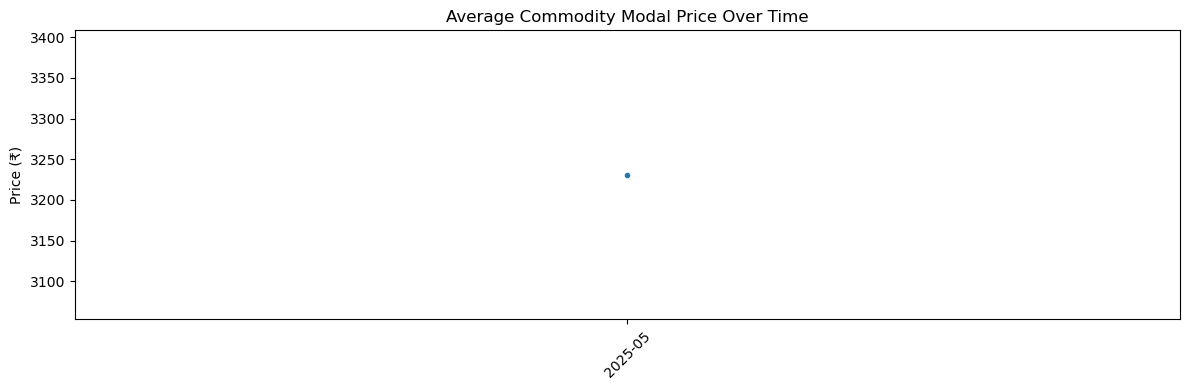

✅ Plot saved to reports/figures/


In [5]:
# ── FEATURE 4: COMMODITY PRICE VOLATILITY ────────────────────────
# This is your unique domain feature — input cost volatility
# directly squeezes MSME working capital

# Calculate monthly price volatility per commodity
df_commodity['year_month'] = df_commodity['date'].dt.to_period('M')

# Overall price volatility index (rolling std)
commodity_volatility = df_commodity.groupby('year_month').agg(
    avg_modal_price=('modal_price', 'mean'),
    price_std=('modal_price', 'std'),
    price_min=('modal_price', 'min'),
    price_max=('modal_price', 'max')
).reset_index()

# Price volatility ratio = std/mean (coefficient of variation)
# Higher = more volatile = more working capital stress
commodity_volatility['price_volatility_index'] = (
    commodity_volatility['price_std'] /
    (commodity_volatility['avg_modal_price'] + 1)
)

# Price spike indicator — month over month change
commodity_volatility['avg_modal_price_lag1'] = commodity_volatility['avg_modal_price'].shift(1)
commodity_volatility['price_mom_change'] = (
    (commodity_volatility['avg_modal_price'] - commodity_volatility['avg_modal_price_lag1']) /
    (commodity_volatility['avg_modal_price_lag1'] + 1)
)

# Flag months with >20% price spike
commodity_volatility['price_spike_flag'] = (
    commodity_volatility['price_mom_change'].abs() > 0.20
).astype(int)

print("Commodity price volatility features:")
print(commodity_volatility.tail(10).round(3))
print(f"\nMonths with >20% price spike: {commodity_volatility['price_spike_flag'].sum()}")
print(f"Overall volatility index mean: {commodity_volatility['price_volatility_index'].mean():.3f}")

# Plot price trend
plt.figure(figsize=(12, 4))
plt.plot(commodity_volatility['year_month'].astype(str),
         commodity_volatility['avg_modal_price'], marker='o', markersize=3)
plt.xticks(rotation=45)
plt.title('Average Commodity Modal Price Over Time')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.savefig('../reports/figures/commodity_price_trend.png', dpi=150)
plt.show()
print("✅ Plot saved to reports/figures/")

Top 15 most volatile commodities in dataset:
            commodity   mean_price  volatility_index  price_range_ratio  count
0   Long Melon(Kakri)  2410.000000             0.967              1.701      3
1     Leafy Vegetable  2937.500000             0.817              1.787      4
2              Tomato  1447.354839             0.726              6.594    155
3    Cucumbar(Kheera)  1753.724490             0.637              3.448     98
4             Cabbage  1542.724638             0.632              2.526     69
5        Mint(Pudina)  3833.333333             0.616              1.174      3
6        Bitter gourd  3424.488636             0.601              2.219     88
7              Potato  1505.974026             0.591              3.069    154
8         Round gourd   973.333333             0.568              1.078      3
9             Pumpkin  1245.500000             0.550              2.968     80
10              Beans  6020.000000             0.549              1.395      5
11     

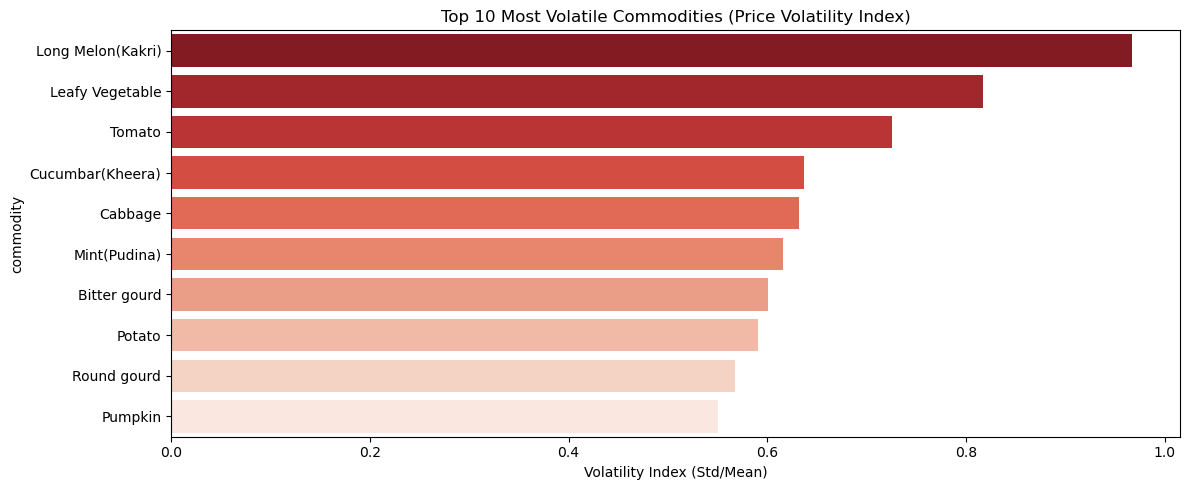

✅ Volatility plot saved


In [6]:
# ── FEATURE 4 (REVISED): SYNTHETIC VOLATILITY FEATURES ───────────
# Our commodity dataset has limited time range
# We create volatility features based on price spread within the dataset
# and document this limitation honestly in the technical report

# Price spread ratio per commodity type
commodity_stats = df_commodity.groupby('commodity').agg(
    mean_price=('modal_price', 'mean'),
    std_price=('modal_price', 'std'),
    min_price=('modal_price', 'min'),
    max_price=('modal_price', 'max'),
    count=('modal_price', 'count')
).reset_index()

commodity_stats['volatility_index'] = (
    commodity_stats['std_price'] /
    (commodity_stats['mean_price'] + 1)
).round(3)

commodity_stats['price_range_ratio'] = (
    (commodity_stats['max_price'] - commodity_stats['min_price']) /
    (commodity_stats['mean_price'] + 1)
).round(3)

# Sort by most volatile commodities
commodity_stats = commodity_stats.sort_values(
    'volatility_index', ascending=False
).reset_index(drop=True)

print("Top 15 most volatile commodities in dataset:")
print(commodity_stats[['commodity', 'mean_price', 'volatility_index',
                         'price_range_ratio', 'count']].head(15).to_string())

# Overall market volatility score to attach to main dataset
market_volatility_score = commodity_stats['volatility_index'].mean()
df_features['market_volatility_score'] = market_volatility_score
print(f"\nOverall market volatility score: {market_volatility_score:.3f}")

# Plot top 10 most volatile commodities
plt.figure(figsize=(12, 5))
top10 = commodity_stats.head(10)
sns.barplot(data=top10, x='volatility_index', y='commodity', palette='Reds_r')
plt.title('Top 10 Most Volatile Commodities (Price Volatility Index)')
plt.xlabel('Volatility Index (Std/Mean)')
plt.tight_layout()
plt.savefig('../reports/figures/commodity_volatility.png', dpi=150)
plt.show()
print("✅ Volatility plot saved")

In [7]:
# ── FEATURE 5: ENQUIRY BEHAVIOUR ─────────────────────────────────
# Too many credit enquiries = desperate for credit = stress signal

df_features['enquiry_acceleration'] = (
    df_features['enq_L3m'] * 4 +    # last 3 months weighted most
    df_features['enq_L6m'] * 2 +
    df_features['enq_L12m'] * 1
)

# Enquiry to approval ratio — many enquiries but few approvals = rejected often
df_features['enquiry_rejection_proxy'] = np.where(
    df_features['tot_enq'] > 0,
    df_features['tot_enq'] / (df_features['Tot_Active_TL'] + 1),
    0
)

# ── FEATURE 6: INCOME AND EXPOSURE FEATURES ──────────────────────

# Debt to income proxy
df_features['debt_burden'] = np.where(
    df_features['NETMONTHLYINCOME'] > 0,
    df_features['max_unsec_exposure_inPct'] / (df_features['NETMONTHLYINCOME'] + 1),
    0
)

# Income stability proxy
df_features['income_employment_score'] = (
    df_features['NETMONTHLYINCOME'] /
    (df_features['NETMONTHLYINCOME'].max() + 1) +
    df_features['Time_With_Curr_Empr'] /
    (df_features['Time_With_Curr_Empr'].max() + 1)
)

print("Enquiry and income features created:")
print(df_features[['enquiry_acceleration', 'enquiry_rejection_proxy',
                    'debt_burden', 'income_employment_score']].describe().round(3))

Enquiry and income features created:
       enquiry_acceleration  enquiry_rejection_proxy  debt_burden  \
count             51336.000                51336.000    51336.000   
mean                 11.480                    1.816        3.705   
std                  16.774                    1.726      410.399   
min                   0.000                    0.048        0.000   
25%                   1.000                    0.833        0.000   
50%                   8.000                    1.500        0.000   
75%                  14.000                    2.250        0.000   
max                 359.000                   50.000    86900.000   

       income_employment_score  
count                51336.000  
mean                     0.119  
std                      0.076  
min                      0.008  
25%                      0.068  
50%                      0.102  
75%                      0.145  
max                      1.034  


In [8]:
# ── ASSEMBLE FINAL FEATURE MATRIX ────────────────────────────────

# Cap extreme outliers in debt_burden
df_features['debt_burden'] = df_features['debt_burden'].clip(0, 
    df_features['debt_burden'].quantile(0.99))

# Select all engineered features + original key features + target
engineered_features = [
    # Engineered features
    'delinquency_severity', 'delinq_trend', 'dpd_stress',
    'cc_utilization_risk', 'pl_utilization_risk', 'credit_stress_score',
    'unsecured_loan_ratio', 'recent_loan_hunger', 'closure_rate',
    'missed_payment_ratio', 'market_volatility_score',
    'enquiry_acceleration', 'enquiry_rejection_proxy',
    'debt_burden', 'income_employment_score',
]

# Key original features to keep
original_features = [
    'Credit_Score', 'NETMONTHLYINCOME', 'AGE',
    'Time_With_Curr_Empr', 'Tot_Active_TL', 'Tot_Closed_TL',
    'CC_utilization', 'PL_utilization',
    'num_times_delinquent', 'tot_enq',
    'max_unsec_exposure_inPct'
]

# Target
target = ['stress_label']

# Build final feature matrix
feature_cols = engineered_features + original_features
df_final = df_features[feature_cols + target].copy()

print(f"Final feature matrix shape: {df_final.shape}")
print(f"Engineered features: {len(engineered_features)}")
print(f"Original features kept: {len(original_features)}")
print(f"Total features: {len(feature_cols)}")
print(f"\nTarget distribution:")
print(df_final['stress_label'].value_counts())
print(f"Stress rate: {df_final['stress_label'].mean():.1%}")
print(f"\nAny nulls: {df_final.isnull().sum().sum()}")

# Save final feature matrix
df_final.to_cs

Final feature matrix shape: (51336, 27)
Engineered features: 15
Original features kept: 11
Total features: 26

Target distribution:
stress_label
0    32199
1    19137
Name: count, dtype: int64
Stress rate: 37.3%

Any nulls: 0


AttributeError: 'DataFrame' object has no attribute 'to_cs'